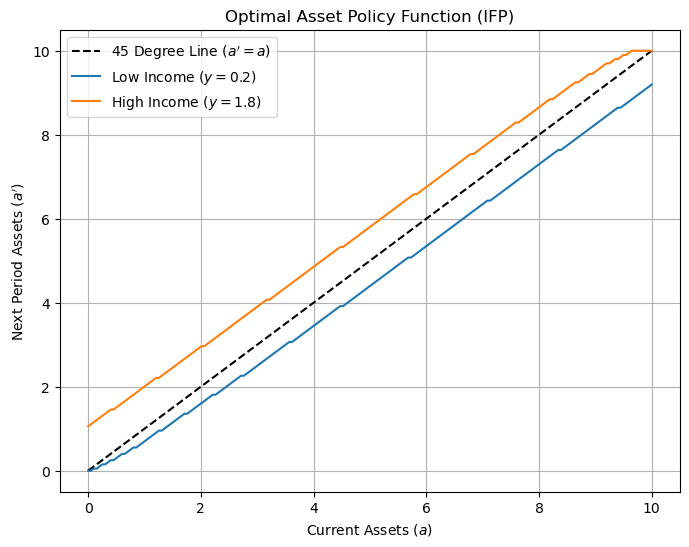

In [5]:
import numpy as np
import quantecon as qe
import matplotlib.pyplot as plt

# 1. パラメータとグリッドの設定
r = 0.04                        # 粗利子率 (R = 1 + r)
beta = 0.96                     # 割引因子
gamma = 1.5                     # 危険回避度（相対的リスク回避度）
y_states = np.array([0.2, 1.8]) # 所得の状態 [低所得, 高所得]
P = np.array([[0.7, 0.3],       # 所得状態のマルコフ推移確率
              [0.3, 0.7]])
a_grid = np.linspace(0, 10, 200) # 資産の離散グリッド (0から10まで200分割)

# 状態空間(現在の資産×所得)と行動空間(次期の資産)のサイズ設定
n_a = len(a_grid)
n_y = len(y_states)
n_s = n_a * n_y  # 総状態数
n_c = n_a        # 総行動数

# 2. 報酬行列(R)と遷移確率行列(Q)の構築
R = np.full((n_s, n_c), -np.inf)
Q = np.zeros((n_s, n_c, n_s))

for s in range(n_s):
    a_idx = s // n_y  # 現在の資産インデックス
    y_idx = s % n_y   # 現在の所得インデックス
    a = a_grid[a_idx]
    y = y_states[y_idx]
    
    for a_next_idx in range(n_c):
        a_next = a_grid[a_next_idx]
        
        # 予算制約から消費量cを計算
        c = (1 + r) * a + y - a_next
        
        # 消費が正の場合のみ効用を計算（負の場合は -inf のままペナルティ）
        if c > 0:
            R[s, a_next_idx] = (c**(1 - gamma) - 1) / (1 - gamma)
            
            # 次期の所得状態への遷移確率を設定
            for y_next_idx in range(n_y):
                s_next = a_next_idx * n_y + y_next_idx
                Q[s, a_next_idx, s_next] = P[y_idx, y_next_idx]

# 3. DiscreteDPによるモデルの計算
ddp = qe.markov.DiscreteDP(R, Q, beta)
res = ddp.solve(method='value_iteration')

# 4. 最適政策（次期資産a'）の抽出と図示
# res.sigma は各状態に対する最適な行動(a_next_idx)を格納しているため、それを元のグリッド値に戻す
optimal_a_next = a_grid[res.sigma].reshape(n_a, n_y)

plt.figure(figsize=(8, 6))
plt.plot(a_grid, a_grid, 'k--', label="45 Degree Line ($a' = a$)")
plt.plot(a_grid, optimal_a_next[:, 0], label=f"Low Income ($y={y_states[0]}$)")
plt.plot(a_grid, optimal_a_next[:, 1], label=f"High Income ($y={y_states[1]}$)")
plt.xlabel("Current Assets ($a$)")
plt.ylabel("Next Period Assets ($a'$)")
plt.title("Optimal Asset Policy Function (IFP)")
plt.legend()
plt.grid()
plt.show()